In [24]:
import torch

import numpy as np
from matplotlib import pyplot as plt

import cv2

import os
import sys

from tqdm.auto import tqdm

from matplotlib import pyplot as plt

sys.path.append(os.path.abspath("../BoardDetector_Yolo/"))
from BoardDetector_YOLO import BoardDetector_YOLO

import importlib
import BoundedCornerExtractor
importlib.reload(BoundedCornerExtractor);

In [2]:
bd = BoardDetector_YOLO()
CE = BoundedCornerExtractor.BoundedCornerExtractor()

img_size = 256

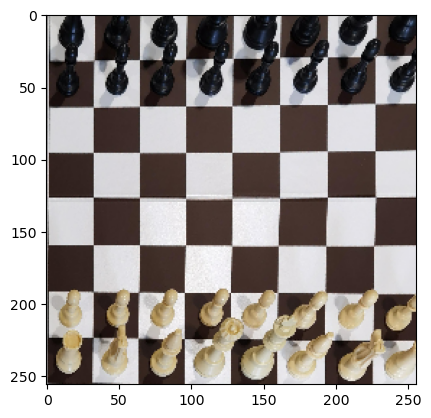

In [21]:
def process_img(img_path):
    img = torch.tensor(plt.imread(img_path))
    bd.set_img(img)
    mask, conf = bd.predict()

    img_gray = img.numpy()

    CE = BoundedCornerExtractor.BoundedCornerExtractor()

    CE.setImg(img_gray, mask)
    CE.apply()
    M, corners, mask_fit, error = CE.fitBoard()

    dst = np.array([
        [0,0],
        [img_size, 0],
        [img_size, img_size],
        [0, img_size],
    ], dtype=np.float32)
    M = cv2.getPerspectiveTransform(corners.cpu().numpy(), dst)
    warped_img = cv2.warpPerspective(img.cpu().numpy(), M, (img_size, img_size))

    return warped_img

img_path = "../data/image_0.jpg"
# img_path = "../data/data_manual/1741715439429.jpg"
warped_img = process_img(img_path)
plt.imshow(warped_img);

In [26]:
dir_path = [
    os.path.abspath("../data/data2/"),
    os.path.abspath("../data/data_manual/"),
]

dir_out = os.path.abspath("../data/data_warped/")

for dir in dir_path:
    for file in tqdm(os.listdir(dir)):
        img_path = os.path.join(dir, file)
        try:
            warped_img = process_img(img_path)
        except Exception as e:
            continue
        with open(os.path.join(dir_out, file), 'wb') as f:
            plt.imsave(f, warped_img)


100%|██████████| 10/10 [00:21<00:00,  2.19s/it]
